### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
df=pd.read_csv(r'D:\DP\Data\customer_support_tickets.csv')

In [3]:
df.head()

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,7/2/2025,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,6/28/2025,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2/5/2025,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,3/20/2025,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,4/27/2025,40,David Kim,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Ticket_ID              20000 non-null  object
 1   Customer_Name          20000 non-null  object
 2   Customer_Email         20000 non-null  object
 3   Ticket_Subject         20000 non-null  object
 4   Ticket_Description     20000 non-null  object
 5   Issue_Category         20000 non-null  object
 6   Priority_Level         20000 non-null  object
 7   Ticket_Channel         20000 non-null  object
 8   Submission_Date        20000 non-null  object
 9   Resolution_Time_Hours  20000 non-null  int64 
 10  Assigned_Agent         20000 non-null  object
 11  Satisfaction_Score     20000 non-null  int64 
dtypes: int64(2), object(10)
memory usage: 1.8+ MB


In [5]:
df.drop(columns=['Ticket_ID','Customer_Name','Customer_Email'], inplace=True)

In [6]:
df

,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,7/2/2025,43,David Kim,5
1,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,6/28/2025,41,Elena Rodriguez,5
2,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2/5/2025,7,Anya Sharma,5
3,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,3/20/2025,41,Anya Sharma,5
4,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,4/27/2025,40,David Kim,5
...,...,...,...,...,...,...,...,...,...
19995,Installation issue - Think,"Hi Support, The application crashes every time...",Technical,High,Web Form,2/5/2025,6,Anya Sharma,4
19996,Alert notification - Reality,"Hi Support, I received a suspicious email clai...",Fraud,Critical,Chat,8/7/2024,10,Elena Rodriguez,3
19997,Subscription upgrade - Spring,"Hi Support, My profile picture is not updating...",Account,Medium,Web Form,10/7/2025,2,David Kim,4
19998,Suspicious charge - Even,"Hi Support, I have been trying to update my pa...",Billing,High,Web Form,1/31/2024,8,Anya Sharma,1


In [7]:
df['Submission_Date']=pd.to_datetime(df['Submission_Date'])

In [8]:
nulls = df.isnull().sum()
nulls_percent = (nulls / len(df)) * 100
nulls_df = pd.DataFrame({'Null Count': nulls, 'Null Percentage': nulls_percent}).T
print(nulls_df)

                 Ticket_Subject  Ticket_Description  Issue_Category  \
Null Count                  0.0                 0.0             0.0   
Null Percentage             0.0                 0.0             0.0   

                 Priority_Level  Ticket_Channel  Submission_Date  \
Null Count                  0.0             0.0              0.0   
Null Percentage             0.0             0.0              0.0   

                 Resolution_Time_Hours  Assigned_Agent  Satisfaction_Score  
Null Count                         0.0             0.0                 0.0  
Null Percentage                    0.0             0.0                 0.0  


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Ticket_Subject         20000 non-null  object        
 1   Ticket_Description     20000 non-null  object        
 2   Issue_Category         20000 non-null  object        
 3   Priority_Level         20000 non-null  object        
 4   Ticket_Channel         20000 non-null  object        
 5   Submission_Date        20000 non-null  datetime64[ns]
 6   Resolution_Time_Hours  20000 non-null  int64         
 7   Assigned_Agent         20000 non-null  object        
 8   Satisfaction_Score     20000 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 1.4+ MB


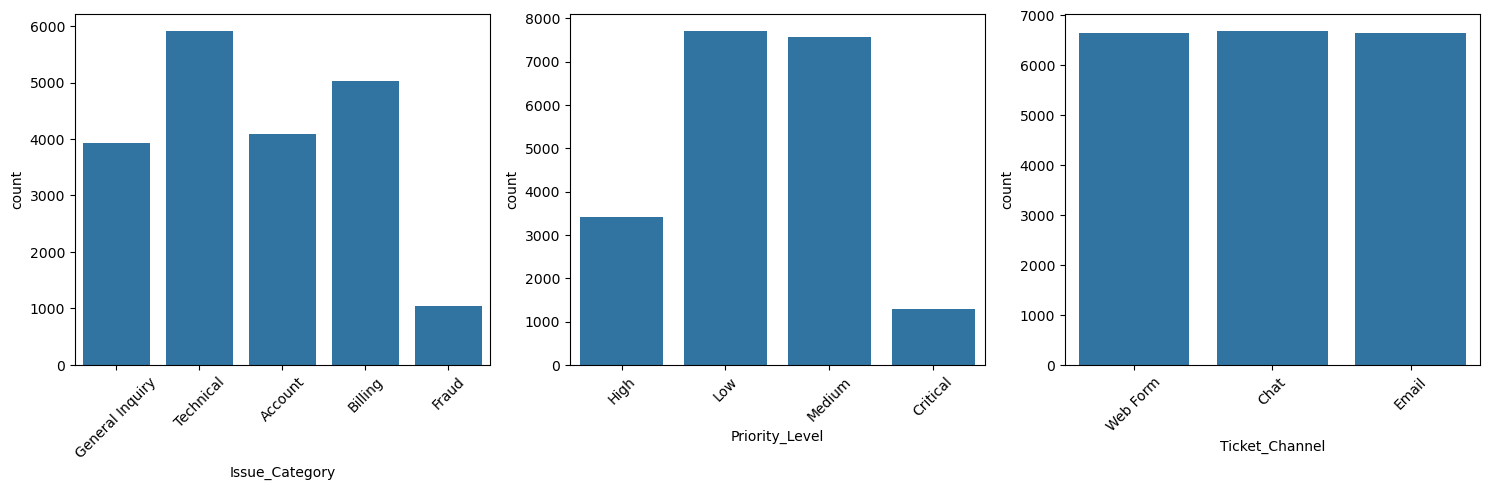

In [14]:
cat_cols=['Issue_Category', 'Priority_Level','Ticket_Channel']
plt.figure(figsize=(15,5))
for i,col in enumerate(cat_cols):
    plt.subplot(1,3,i+1)
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\7520\AppData\Local\Temp\ipykernel_9576\960927576.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Satisfaction_Score', palette='pastel', order=sorted(df['Satisfaction_Score'].unique()), edgecolor='black')


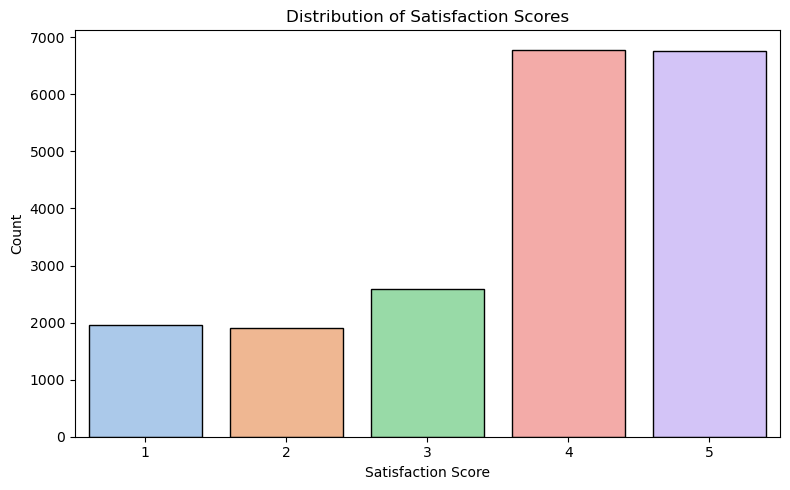

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Satisfaction_Score', palette='pastel', order=sorted(df['Satisfaction_Score'].unique()), edgecolor='black')
plt.title('Distribution of Satisfaction Scores')
plt.xlabel('Satisfaction Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Description Length Summary:
count    20000.00000
mean        99.61870
std         14.74394
min         60.00000
25%         89.00000
50%         99.00000
75%        110.00000
max        153.00000
Name: description_length, dtype: float64

Word Count Summary:
count    20000.000000
mean        16.931000
std          2.391114
min         10.000000
25%         15.000000
50%         17.000000
75%         19.000000
max         23.000000
Name: description_word_count, dtype: float64


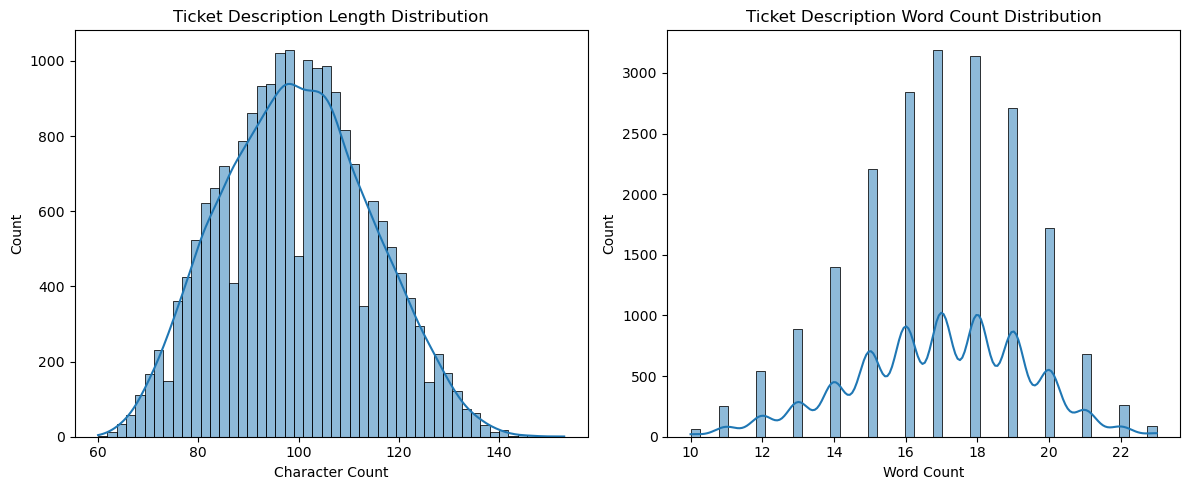

In [ ]:

df['description_length'] = df['Ticket_Description'].str.len()
df['description_word_count'] = df['Ticket_Description'].str.split().str.len()

print("Description Length Summary:")
print(df['description_length'].describe())
print("\nWord Count Summary:")
print(df['description_word_count'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['description_length'], bins=50, kde=True)
plt.title('Ticket Description Length Distribution')
plt.xlabel('Character Count')

plt.subplot(1, 2, 2)
sns.histplot(df['description_word_count'], bins=50, kde=True)
plt.title('Ticket Description Word Count Distribution')
plt.xlabel('Word Count')

plt.tight_layout()
plt.show()

In [16]:
df

,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score,description_length,description_word_count
0,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5,80,13
1,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5,98,17
2,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5,86,16
3,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5,100,17
4,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5,98,18
...,...,...,...,...,...,...,...,...,...,...,...
19995,Installation issue - Think,"Hi Support, The application crashes every time...",Technical,High,Web Form,2025-02-05,6,Anya Sharma,4,107,17
19996,Alert notification - Reality,"Hi Support, I received a suspicious email clai...",Fraud,Critical,Chat,2024-08-07,10,Elena Rodriguez,3,110,18
19997,Subscription upgrade - Spring,"Hi Support, My profile picture is not updating...",Account,Medium,Web Form,2025-10-07,2,David Kim,4,66,11
19998,Suspicious charge - Even,"Hi Support, I have been trying to update my pa...",Billing,High,Web Form,2024-01-31,8,Anya Sharma,1,115,20


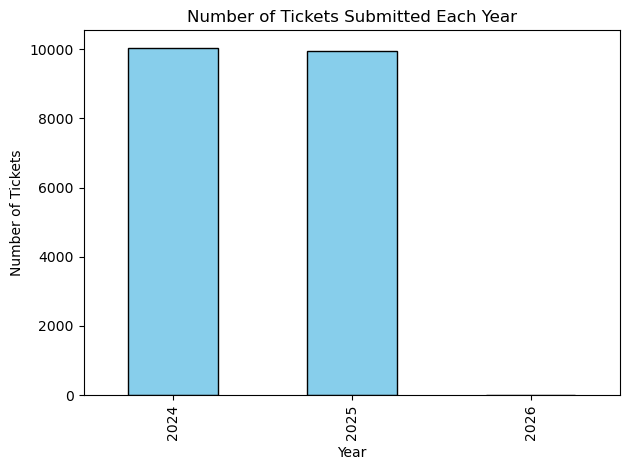

In [27]:
yearly_counts = df['Submission_Date'].dt.year.value_counts().sort_index()
yearly_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Tickets Submitted Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.show()